# QUESTION - 1

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.linalg import toeplitz

## PART - 1A

(450, 800, 3)


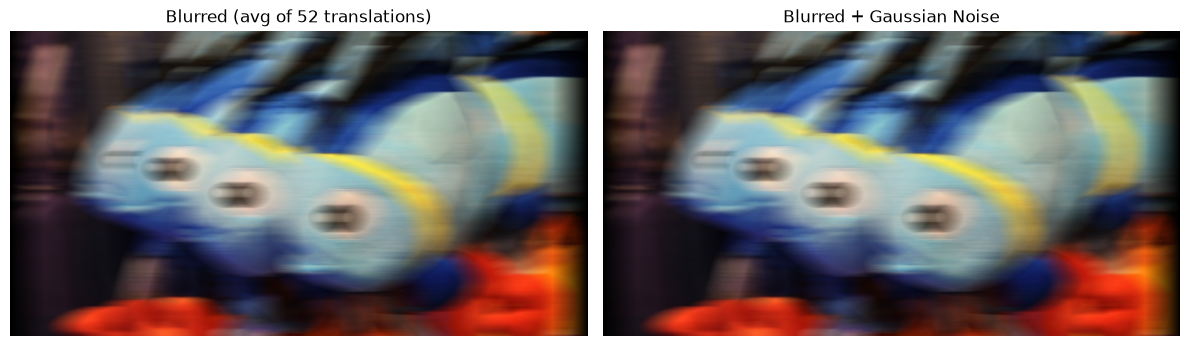

In [33]:
I = plt.imread('fish.png').astype(float) / 255.0
print(I.shape)
gauss_data = loadmat('gaussNoise.mat')
gauss_noise = gauss_data['gaussNoise']
I = plt.imread('fish.png').astype(float)  # Already [0,1]
M, N, C = I.shape  # 450, 800, 3

gauss_noise = loadmat('gaussNoise.mat')['gaussNoise']  # Mean 0, std 1 in 255-scale


blurred = np.zeros((M, N + 51, 3))
for t in range(52):
    left = np.zeros((M, t, 3))
    right = np.zeros((M, 51 - t, 3))
    translated = np.concatenate([left, I, right], axis=1)
    blurred += translated
blurred /= 52

noise = gauss_noise / 255.0
blurred_noisy = blurred + noise

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.clip(blurred, 0, 1))
plt.title('Blurred (avg of 52 translations)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.clip(blurred_noisy, 0, 1))
plt.title('Blurred + Gaussian Noise')
plt.axis('off')

plt.tight_layout()
plt.show()


## PART - 1B

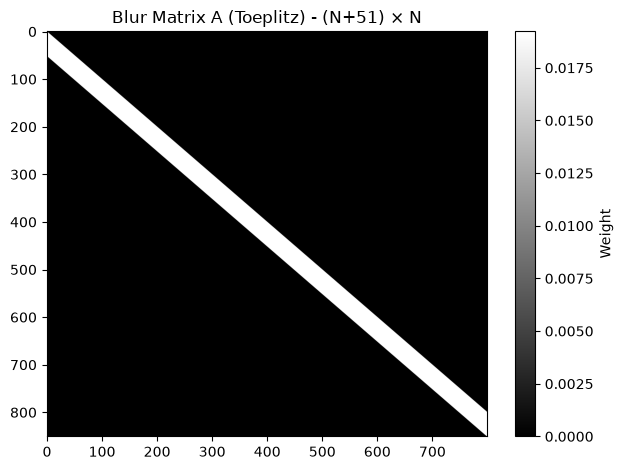

In [34]:
c = np.zeros(N+51)
c[0:52] = 1/52

r = np.zeros(N)
r[0] = 1/52

A = toeplitz(c, r)
plt.imshow(A, cmap='gray', aspect='auto')
plt.title('Blur Matrix A (Toeplitz) - (N+51) × N')
plt.colorbar(label='Weight')
plt.tight_layout()
plt.show()

## PART - 1C

RMSE: 0.333941


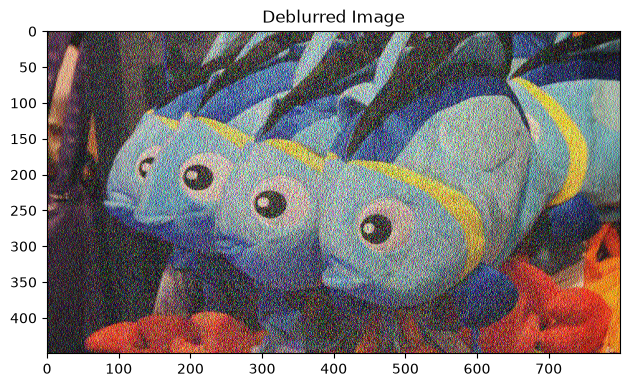

In [35]:
A_pinv = np.linalg.pinv(A)  # N x (N+51)
deblurred = np.zeros((M, N, 3))
for ch in range(3):
    for row in range(M):
        deblurred[row, :, ch] = A_pinv @ blurred_noisy[row, :, ch]

deblurred = np.clip(deblurred, 0, 1)
rmse = np.sqrt(np.mean((I - deblurred) ** 2))
print(f"RMSE: {rmse:.6f}")

plt.imshow(deblurred)
plt.title('Deblurred Image')
plt.tight_layout()
plt.show()

## PART - 1D

The deblurred image recovers the major structures and details of the original image, and the horizontal motion blur is significantly reduced. But, the recovered image contains grainy and coloured noise, particularly in smooth regions and near edges. This occurs because the blur was modeled as 52-point moving-average operation, whose inverse is ill-conditioned. The pseudo-inverse amplifies the high-frequency components that were attenuated by the blur, but it also amplifies the Gaussian noise present in it. Hence the deblurring technique can recover the sharpness at the cost of noise amplification.
The blur is represented by the matrix \(A\), which performs a 52-point moving average:

$$
y = Ax+n
$$

where \(x\) is the original image, \(y\) is the blurred noisy image, and \(n\) is Gaussian noise.
The deblurring technique uses:

$$
\hat{x}=A^\dagger y
$$

to recover the image.

Therefore,

$$
A^\dagger(Ax+n)
\approx x + A^\dagger n
$$

and the $(A^\dagger n)$ term becomes large when \(A\) has small singular values. 


# QUESTION - 2

In [36]:
code1 = "1010000111000001010000110011110111010111001001100111"
code2 = "1010101010101010101010101010101010101010101010101010"

code1_bits = np.array([int(b) for b in code1])
code2_bits = np.array([int(b) for b in code2])


## PART - 2A

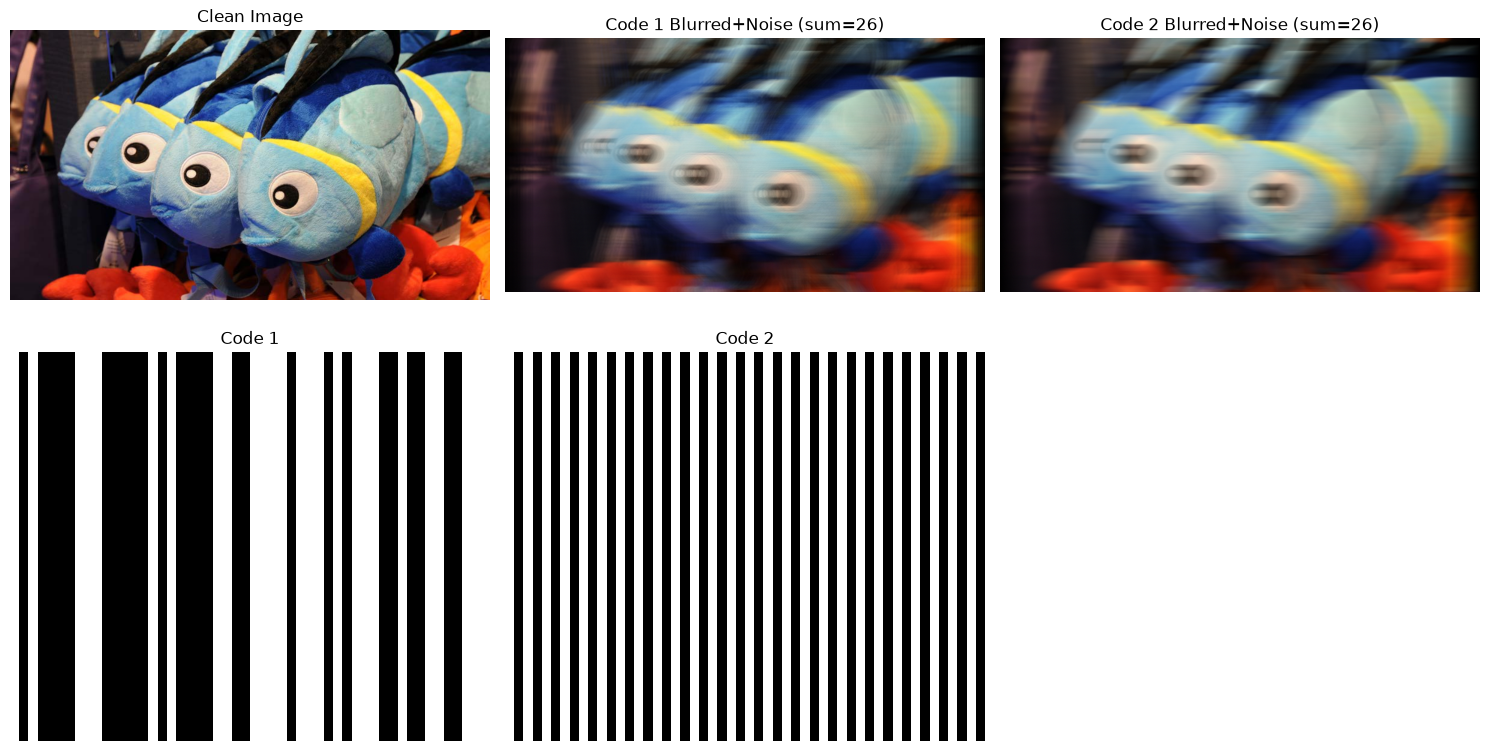

In [37]:
def generate_flutter_blurred(I, code_bits, gauss_noise):
    M, N, C = I.shape
    blurred = np.zeros((M, N + 51, 3))
    
    for t in range(52):
        if code_bits[t] == 1:
            left = np.zeros((M, t, 3))
            right = np.zeros((M, 51 - t, 3))
            translated = np.concatenate([left, I, right], axis=1)
            blurred += translated
    blurred /= code_bits.sum()
    
    noise = gauss_noise / 255.0
    blurred_noisy = blurred + noise
    return blurred, blurred_noisy
blurred1, blurred_noisy1 = generate_flutter_blurred(I, code1_bits, gauss_noise)
blurred2, blurred_noisy2 = generate_flutter_blurred(I, code2_bits, gauss_noise)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(I); axes[0, 0].set_title('Clean Image'); axes[0, 0].axis('off')
axes[0, 1].imshow(np.clip(blurred_noisy1, 0, 1)); axes[0, 1].set_title(f'Code 1 Blurred+Noise (sum={code1_bits.sum()})'); axes[0, 1].axis('off')
axes[0, 2].imshow(np.clip(blurred_noisy2, 0, 1)); axes[0, 2].set_title(f'Code 2 Blurred+Noise (sum={code2_bits.sum()})'); axes[0, 2].axis('off')
axes[1, 0].imshow(code1_bits.reshape(1, -1), cmap='gray', aspect='auto'); axes[1, 0].set_title('Code 1'); axes[1, 0].axis('off')
axes[1, 1].imshow(code2_bits.reshape(1, -1), cmap='gray', aspect='auto'); axes[1, 1].set_title('Code 2'); axes[1, 1].axis('off')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()


## PART - 2B

A1 shape: (851, 800), A2 shape: (851, 800)


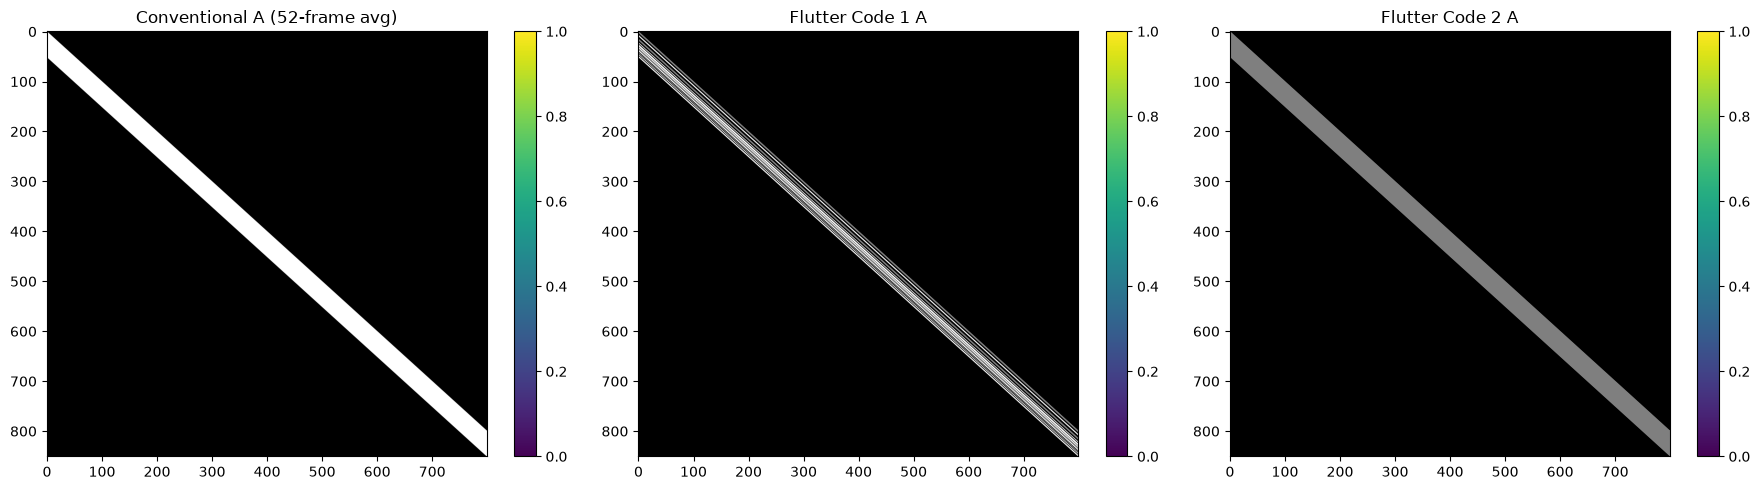

In [38]:
def build_flutter_A(code_bits, N):
    c = np.zeros(N + 51)
    for t in range(52):
        if code_bits[t] == 1:
            c[t] = 1 / code_bits.sum()
    
    r = np.zeros(N)
    if code_bits[0] == 1:
        r[0] = 1 / code_bits.sum()
    
    A = toeplitz(c, r)
    return A

A1 = build_flutter_A(code1_bits, N)
A2 = build_flutter_A(code2_bits, N)

print(f"A1 shape: {A1.shape}, A2 shape: {A2.shape}")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
c_conv = np.zeros(N + 51); c_conv[0:52] = 1/52
r_conv = np.zeros(N); r_conv[0] = 1/52
A_conv = toeplitz(c_conv, r_conv)

axes[0].imshow(A_conv, cmap='gray', aspect='auto')
axes[0].set_title('Conventional A (52-frame avg)')
plt.colorbar(plt.cm.ScalarMappable(), ax=axes[0])

axes[1].imshow(A1, cmap='gray', aspect='auto')
axes[1].set_title(f'Flutter Code 1 A')
plt.colorbar(plt.cm.ScalarMappable(), ax=axes[1])

axes[2].imshow(A2, cmap='gray', aspect='auto')
axes[2].set_title(f'Flutter Code 2 A')
plt.colorbar(plt.cm.ScalarMappable(), ax=axes[2])
plt.tight_layout()
plt.show()


## PART - 2C

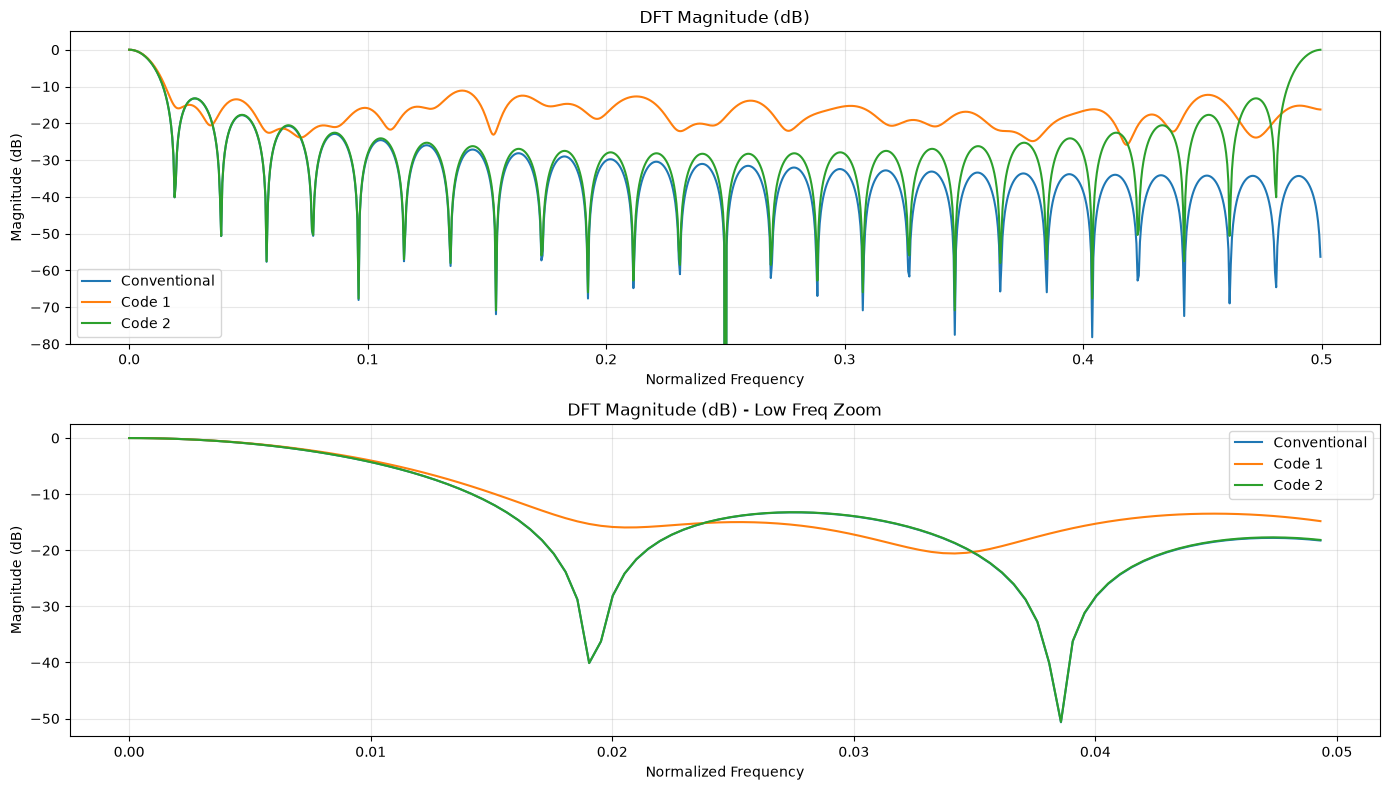

In [39]:
h_conv = A_conv[:, 0] 
h1 = A1[:, 0]
h2 = A2[:, 0]

L = 2048
H_conv = np.fft.fft(h_conv, L)
H1 = np.fft.fft(h1, L)
H2 = np.fft.fft(h2, L)

freq = np.fft.fftfreq(L)

pos = freq >= 0
freq = freq[pos]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(freq, 20*np.log10(np.abs(H_conv[pos]) + 1e-12), label='Conventional')
axes[0].plot(freq, 20*np.log10(np.abs(H1[pos]) + 1e-12), label='Code 1')
axes[0].plot(freq, 20*np.log10(np.abs(H2[pos]) + 1e-12), label='Code 2')
axes[0].set_title('DFT Magnitude (dB)')
axes[0].set_xlabel('Normalized Frequency'); axes[0].set_ylabel('Magnitude (dB)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-80, 5)

axes[1].plot(freq[:L//20], 20*np.log10(np.abs(H_conv[pos])[:L//20] + 1e-12), label='Conventional')
axes[1].plot(freq[:L//20], 20*np.log10(np.abs(H1[pos])[:L//20] + 1e-12), label='Code 1')
axes[1].plot(freq[:L//20], 20*np.log10(np.abs(H2[pos])[:L//20] + 1e-12), label='Code 2')
axes[1].set_title('DFT Magnitude (dB) - Low Freq Zoom')
axes[1].set_xlabel('Normalized Frequency'); axes[1].set_ylabel('Magnitude (dB)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Comment : Code 1 has best conditioning preserving high frequencies

## PART - 2D

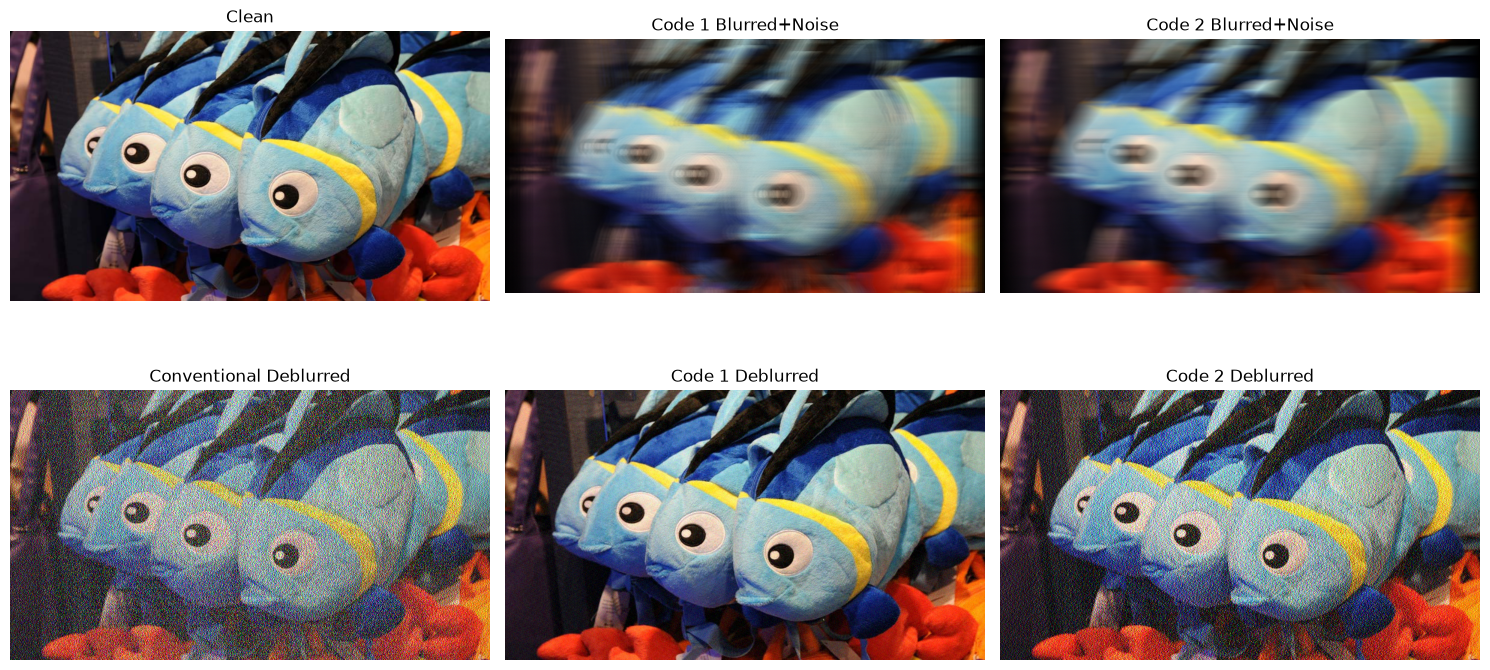

In [40]:
def deblur_flutter(blurred_noisy, A):
    M, _, C = blurred_noisy.shape
    N = A.shape[1]
    
    A_pinv = np.linalg.pinv(A)  
    deblurred = np.zeros((M, N, C))
    for ch in range(C):
        for row in range(M):
            deblurred[row, :, ch] = A_pinv @ blurred_noisy[row, :, ch]
    
    return np.clip(deblurred, 0, 1)

deblurred1 = deblur_flutter(blurred_noisy1, A1)
deblurred2 = deblur_flutter(blurred_noisy2, A2)

deblurred_conv = deblur_flutter(blurred_noisy, A_conv)


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(I); axes[0, 0].set_title('Clean'); axes[0, 0].axis('off')
axes[0, 1].imshow(np.clip(blurred_noisy1, 0, 1)); axes[0, 1].set_title('Code 1 Blurred+Noise'); axes[0, 1].axis('off')
axes[0, 2].imshow(np.clip(blurred_noisy2, 0, 1)); axes[0, 2].set_title('Code 2 Blurred+Noise'); axes[0, 2].axis('off')
axes[1, 0].imshow(deblurred_conv); axes[1, 0].set_title('Conventional Deblurred'); axes[1, 0].axis('off')
axes[1, 1].imshow(deblurred1); axes[1, 1].set_title('Code 1 Deblurred'); axes[1, 1].axis('off')
axes[1, 2].imshow(deblurred2); axes[1, 2].set_title('Code 2 Deblurred'); axes[1, 2].axis('off')
plt.tight_layout()
plt.show()



## PART - 2E

In [41]:
def compute_rmse(clean, deblurred):
    return np.sqrt(np.mean((clean - deblurred) ** 2))

rmse_conv = compute_rmse(I, deblurred_conv)
rmse1 = compute_rmse(I, deblurred1)
rmse2 = compute_rmse(I, deblurred2)

print(f"\nRMSE Comparison:")
print(f"  Conventional: {rmse_conv:.6f}")
print(f"  Code 1:       {rmse1:.6f}")
print(f"  Code 2:       {rmse2:.6f}")



RMSE Comparison:
  Conventional: 0.333941
  Code 1:       0.033469
  Code 2:       0.203550


### Comment on the result

The deblurred images obtained using the three shutter patterns show a significant difference in reconstruction quality. The conventional 52-frame averaging method produces a highly noisy image with noticeable artifacts, giving an RMSE of \(0.333941\). Code 2 gives a better reconstruction than conventional, with an RMSE of \(0.203550\), but the image still contains visible noise and some loss of fine details.
In contrast, Code 1 produces a much sharper image that is visually closer to the original clean image. It also gives a much lower RMSE of \(0.033469\), indicating that the reconstructed image is significantly closer to the original.The difference occurs because the shutter codes produce different blur matrices and therefore have different frequency responses and conditioning. The conventional averaging shutter strongly attenuates certain high-frequency components. When the pseudoinverse is used for deblurring, these suppressed components and the added Gaussian noise are amplified, resulting in strong noise and reconstruction errors.

The flutter-shutter codes are designed to preserve more high-frequency information. Code 1 has a better-conditioned blur matrix and its frequency response has fewer severe attenuations or zeros. Therefore, its pseudoinverse does not amplify the noise as strongly, allowing the high-frequency details of the original image to be recovered more accurately. Code 2 provides some improvement over the conventional shutter but still has stronger attenuation of certain frequencies, resulting in greater noise amplification and a higher RMSE.Thus, the lower RMSE of Code 1 (\(0.033469\)) is consistent with its visually sharper reconstruction and indicates that its shutter pattern is better suited for computational deblurring under the given noise conditions.

## PART - 2F


RMSE Comparison (No Noise):
  Conventional: 5.4848986774422997e-14
  Code 1:       3.2659098849651393e-15
  Code 2:       3.0827024975668234e-14


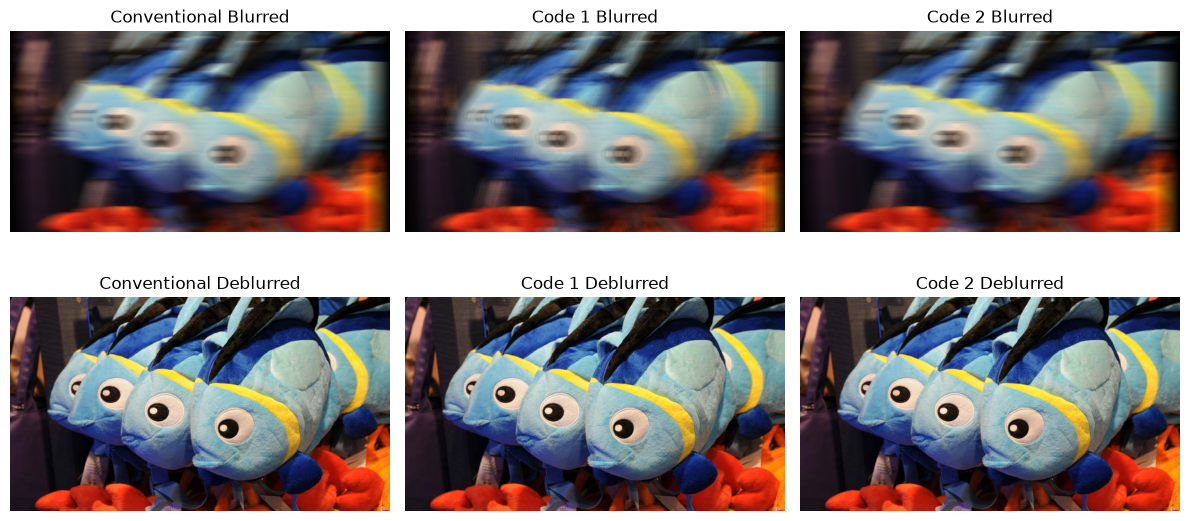

In [42]:
def generate_blurred_no_noise(I, code_bits):
    M, N, C = I.shape
    blurred = np.zeros((M, N + 51, C))
    for t in range(52):
        if code_bits[t] == 1:
            left = np.zeros((M, t, C))
            right = np.zeros((M, 51 - t, C))
            translated = np.concatenate([left, I, right], axis=1)
            blurred += translated
    blurred /= code_bits.sum()
    return blurred

blurred_conv_clean = np.zeros((M, N + 51, 3))
for t in range(52):
    left = np.zeros((M, t, 3))
    right = np.zeros((M, 51 - t, 3))
    translated = np.concatenate([left, I, right], axis=1)
    blurred_conv_clean += translated
blurred_conv_clean /= 52

blurred1_clean = generate_blurred_no_noise(I, code1_bits)
blurred2_clean = generate_blurred_no_noise(I, code2_bits)

def deblur_no_noise(blurred, A):
    M, _, C = blurred.shape
    N = A.shape[1]
    A_pinv = np.linalg.pinv(A)
    deblurred = np.zeros((M, N, C))
    for ch in range(C):
        for row in range(M):
            deblurred[row, :, ch] = A_pinv @ blurred[row, :, ch]
    return np.clip(deblurred, 0, 1)

deblurred_conv_clean = deblur_no_noise(blurred_conv_clean, A_conv)
deblurred1_clean = deblur_no_noise(blurred1_clean, A1)
deblurred2_clean = deblur_no_noise(blurred2_clean, A2)
rmse_conv_clean = compute_rmse(I, deblurred_conv_clean)
rmse1_clean = compute_rmse(I, deblurred1_clean)
rmse2_clean = compute_rmse(I, deblurred2_clean)

print(f"\nRMSE Comparison (No Noise):")
print(f"  Conventional: {rmse_conv_clean}")
print(f"  Code 1:       {rmse1_clean}")
print(f"  Code 2:       {rmse2_clean}")

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# axes[0, 0].imshow(I); axes[0, 0].set_title('Clean'); axes[0, 0].axis('off')
axes[0, 0].imshow(np.clip(blurred_conv_clean, 0, 1))
axes[0, 0].set_title('Conventional Blurred') 
axes[0, 0].axis('off')
axes[0, 1].imshow(np.clip(blurred1_clean, 0, 1))
axes[0, 1].set_title('Code 1 Blurred')
axes[0, 1].axis('off')
axes[0, 2].imshow(np.clip(blurred2_clean, 0, 1))
axes[0, 2].set_title('Code 2 Blurred')
axes[0, 2].axis('off')

axes[1, 0].imshow(deblurred_conv_clean)
axes[1, 0].set_title('Conventional Deblurred')
axes[1, 0].axis('off')
axes[1, 1].imshow(deblurred1_clean)
axes[1, 1].set_title('Code 1 Deblurred')
axes[1, 1].axis('off')
axes[1, 2].imshow(deblurred2_clean)
axes[1, 2].set_title('Code 2 Deblurred')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Comment on the Result

In the absence of noise, all three shutter patterns produce an almost perfect reconstruction after deblurring. The RMSE values are extremely close to zero.
This result is different from Part 2E, where significant differences in reconstruction quality were observed. In Part 2E, Gaussian noise was added to the blurred image. The pseudoinverse amplifies this noise, especially for components corresponding to small singular values of the blur matrix, resulting in visible artifacts and a higher RMSE.

In Part 2F, there is no noise, so the pseudoinverse only needs to invert the blur operation. Since the blur matrices contain sufficient information to reconstruct the original image, the inverse operation recovers the image almost exactly.

Therefore, the large difference between the methods in the noisy case is mainly due to **noise amplification during inversion**. This demonstrates that the main challenge in computational deblurring is the sensitivity of the inverse operation to noise.

# Question - 3

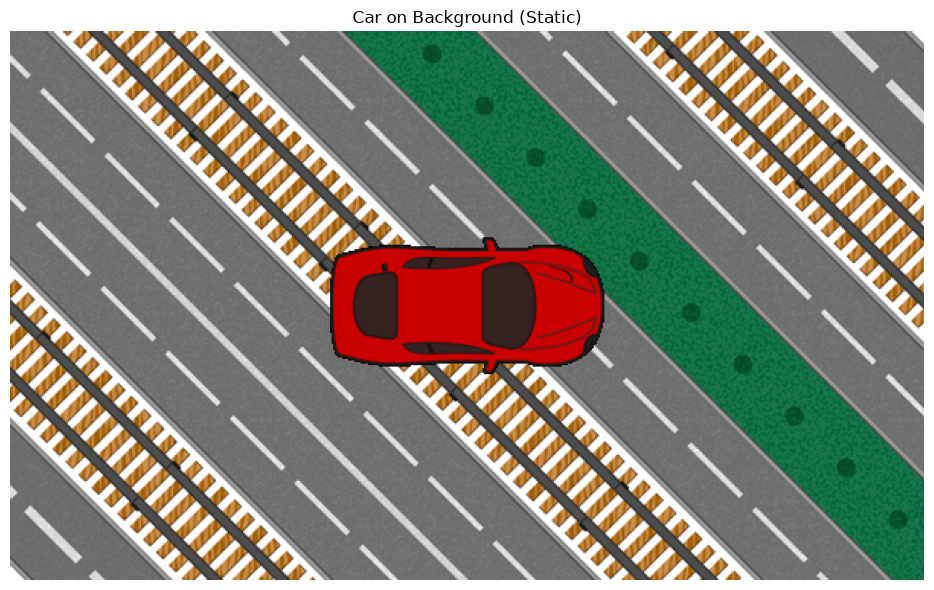

In [59]:
bg = plt.imread('background.png').astype(float)
fg = plt.imread('redcar.png').astype(float)

car_mask = np.any(fg > 0.02, axis=2)
composite = bg.copy()
composite[car_mask] = fg[car_mask]

plt.figure(figsize=(10, 6))
plt.imshow(np.clip(composite, 0, 1))
plt.title('Car on Background (Static)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Part - 3A

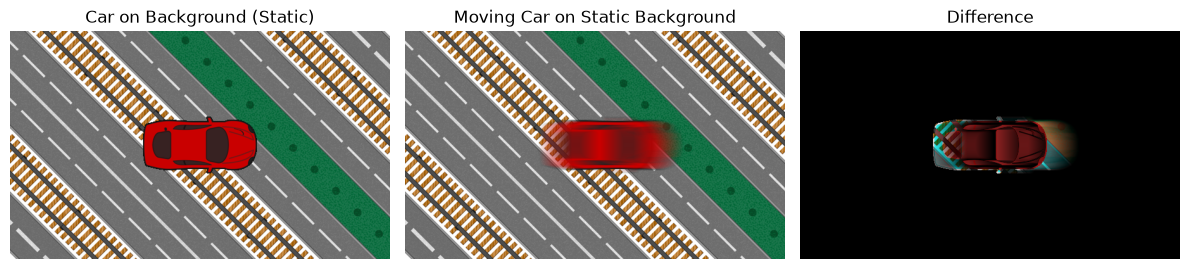

RMSE: 0.06857377526503373


In [64]:
bg = plt.imread('background.png').astype(float)
fg = plt.imread('redcar.png').astype(float)

M, N, C = bg.shape

car_mask = np.any(fg > 0.02, axis=2)  # Create a mask for the car region
car_only = fg.copy()
car_only[~car_mask] = 0  

blurred_car = np.zeros((M, N, C))

for t in range(52):
    translated_car = np.zeros_like(fg)
    translated_mask = np.zeros_like(car_mask)
    
    if t == 0:
        translated_car = car_only.copy()
        translated_mask = car_mask.copy()
    elif t < N:
        translated_car[:, t:, :] = car_only[:, :-t, :]
        translated_mask[:, t:] = car_mask[:, :-t]
    frame = bg.copy()
    frame[translated_mask] = translated_car[translated_mask]
    blurred_car += frame
blurred_car /= 52

difference = np.abs(composite - blurred_car)
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(composite)
axes[0].set_title('Car on Background (Static)')
axes[0].axis('off')
axes[2].imshow(difference)
axes[2].set_title('Difference')
axes[2].axis('off')
axes[1].imshow(np.clip(blurred_car, 0, 1))
axes[1].set_title('Moving Car on Static Background')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print("RMSE:", compute_rmse(composite, blurred_car))

## Part - 3B

[[52.         48.07692308 44.30769231 40.69230769 37.23076923 33.92307692
  30.76923077 27.76923077 24.92307692 22.23076923 19.69230769 17.30769231
  15.07692308 13.         11.07692308  9.30769231  7.69230769  6.23076923
   4.92307692  3.76923077  2.76923077  1.92307692  1.23076923  0.69230769
   0.30769231  0.07692308  0.          0.07692308  0.30769231  0.69230769
   1.23076923  1.92307692  2.76923077  3.76923077  4.92307692  6.23076923
   7.69230769  9.30769231 11.07692308 13.         15.07692308 17.30769231
  19.69230769 22.23076923 24.92307692 27.76923077 30.76923077 33.92307692
  37.23076923 40.69230769 44.30769231 48.07692308 52.        ]]


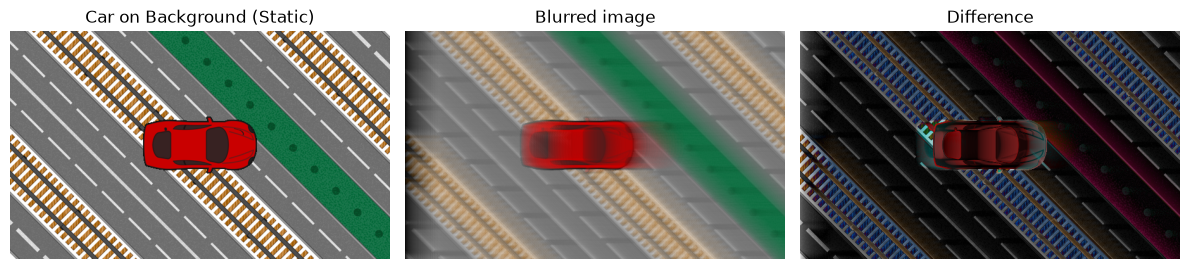

RMSE: 0.18952872561350725


In [105]:
CameraT = loadmat('CameraT.mat')['CameraT']
print(CameraT)
CameraT = CameraT.ravel()

cam_trans = CameraT[:52]
objtrans = np.arange(52) # Assuming linear motion of the car
rel_trans = cam_trans - objtrans

def translate_image(img, mask, tx):
    M,N,C = img.shape
    ti = np.zeros_like(img)
    tm = np.zeros_like(mask)
    if tx == 0:
        ti = img.copy()
        tm = mask.copy()
    elif tx > 0 and tx < N:
        ti[:, tx:, :] = img[:, :-tx, :]
        tm[:, tx:] = mask[:, :-tx]
    elif tx < 0 and -tx < N:
        ti[:, :tx, :] = img[:, -tx:, :]
        tm[:, :tx] = mask[:, -tx:]
    return ti, tm

def bg_move(bg,tx):
    M,N,C = bg.shape
    tbg = np.zeros_like(bg)
    if tx == 0:
        tbg = bg.copy()
    elif tx > 0 and tx < N:
        tbg[:, tx:, :] = bg[:, :-tx, :]
    elif tx < 0 and -tx < N:
        tbg[:, :tx, :] = bg[:, -tx:, :]
    return tbg

blurred_moving_car = np.zeros((M, N, C))
for t in range(52):
    ct = int(round(cam_trans[t]))
    rt = int(round(rel_trans[t]))
    tbg = bg_move(bg, ct)
    tcar, tmask = translate_image(car_only, car_mask, rt)
    frame = tbg.copy()
    frame[tmask] = tcar[tmask]
    blurred_moving_car += frame
    
blurred_moving_car /= 52
difference_moving = np.abs(composite - blurred_moving_car)
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(composite)
axes[0].set_title('Car on Background (Static)')
axes[0].axis('off')
axes[2].imshow(difference_moving)
axes[2].set_title('Difference')
axes[2].axis('off')
axes[1].imshow(np.clip(blurred_moving_car, 0, 1))
axes[1].set_title('Blurred image')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print("RMSE:", compute_rmse(composite, blurred_moving_car))

## Part - 3C

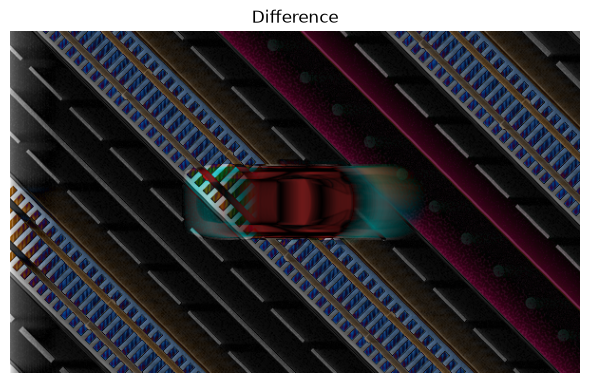

RMSE for the blurred scenarios: 0.19004856667448897


In [106]:
Comparison = abs(blurred_moving_car - blurred_car)
plt.figure(figsize=(6, 5))
plt.imshow(np.clip(Comparison, 0, 1))
plt.title('Difference')
plt.axis('off')
plt.tight_layout()
plt.show()
print("RMSE for the blurred scenarios:", compute_rmse(blurred_moving_car, blurred_car))

### Comparison of the outputs of (a) and (b)

In **part (a)**, only the car is moving while the background remains static. The resulting blurred image therefore shows motion blur mainly around the car. In **part (b)**, both the camera and the car are moving. As a result, the background also becomes blurred, in addition to the motion blur of the car. The relative motion between the car and the camera is different from the camera motion with respect to the background, producing a more complex blur pattern.

Thus, the output in (b) exhibits greater overall distortion than (a). This occurs because the motion in (b) is not limited to the object; the camera motion causes the entire background to move in the image as well. The relative motion between the camera and the car determines the car's apparent motion, while the camera motion determines the background motion.

## Part - 3D

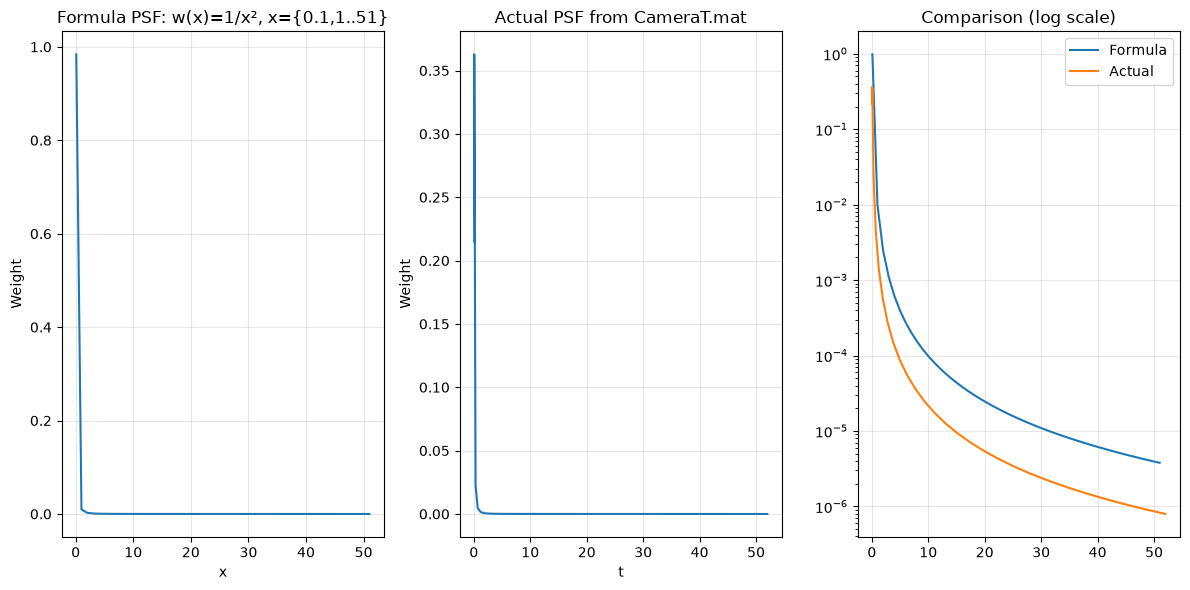

In [107]:
x = np.array([0.1] + list(range(1,52)))
psf_formula = 1.0 / (x**2)
psf_formula /= psf_formula.sum()

actual_x = np.sort(cam_trans) # Symetric translation of camera as per CameraT.mat 
actual_x[actual_x == 0] = 0.1
psf_actual = 1.0 / (actual_x**2)
psf_actual /= psf_actual.sum()

# Plot both
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].plot(x, psf_formula)
axes[0].set_title('Formula PSF: w(x)=1/x², x={0.1,1..51}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Weight'); axes[0].grid(True, alpha=0.3)

axes[1].plot(actual_x, psf_actual)
axes[1].set_title('Actual PSF from CameraT.mat')
axes[1].set_xlabel('t'); axes[1].set_ylabel('Weight'); axes[1].grid(True, alpha=0.3)

axes[2].plot(x, psf_formula, label='Formula')
axes[2].plot(actual_x, psf_actual, label='Actual')
axes[2].set_yscale('log')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_title('Comparison (log scale)')
plt.tight_layout()
plt.show()


## Part - 3E

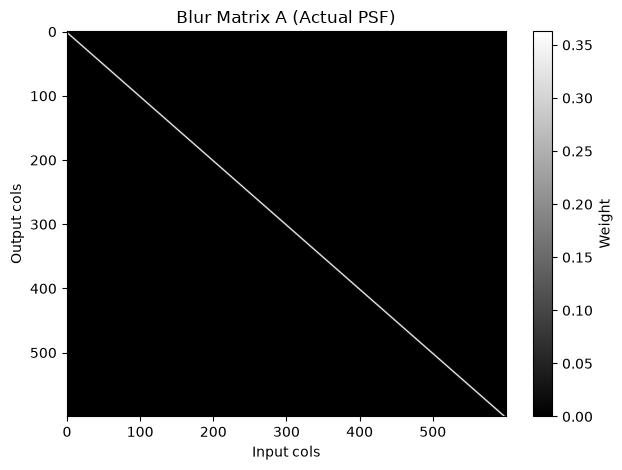

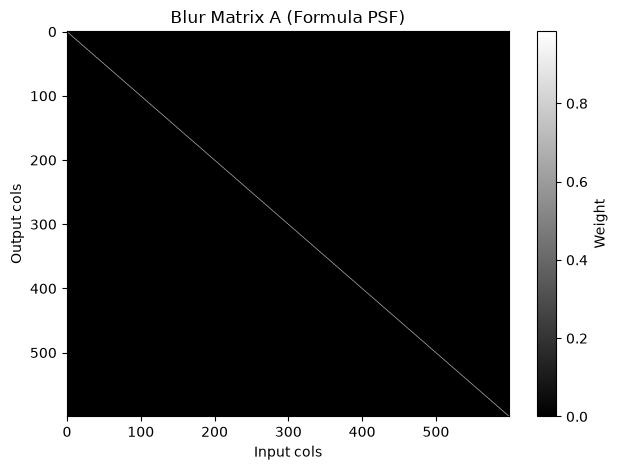

In [108]:
c = np.zeros(N)
c[:len(psf_actual)] = psf_actual
r = np.zeros(N)
r[0] = psf_actual[0]
A_actual = toeplitz(c, r)
plt.imshow(A_actual, cmap='gray', aspect='auto')
plt.title('Blur Matrix A (Actual PSF)')
plt.xlabel('Input cols'); plt.ylabel('Output cols')
plt.colorbar(label='Weight')
plt.tight_layout()
plt.show()

c = np.zeros(N)
c[:len(psf_formula)] = psf_formula
r = np.zeros(N)
r[0] = psf_formula[0]
A_formula = toeplitz(c, r)
plt.imshow(A_formula, cmap='gray', aspect='auto')
plt.title('Blur Matrix A (Formula PSF)')
plt.xlabel('Input cols'); plt.ylabel('Output cols')
plt.colorbar(label='Weight')
plt.tight_layout()
plt.show()

## Part - 3F

RMSE for actual PSF deblurring: 0.189058
RMSE for formula PSF deblurring: 0.189207


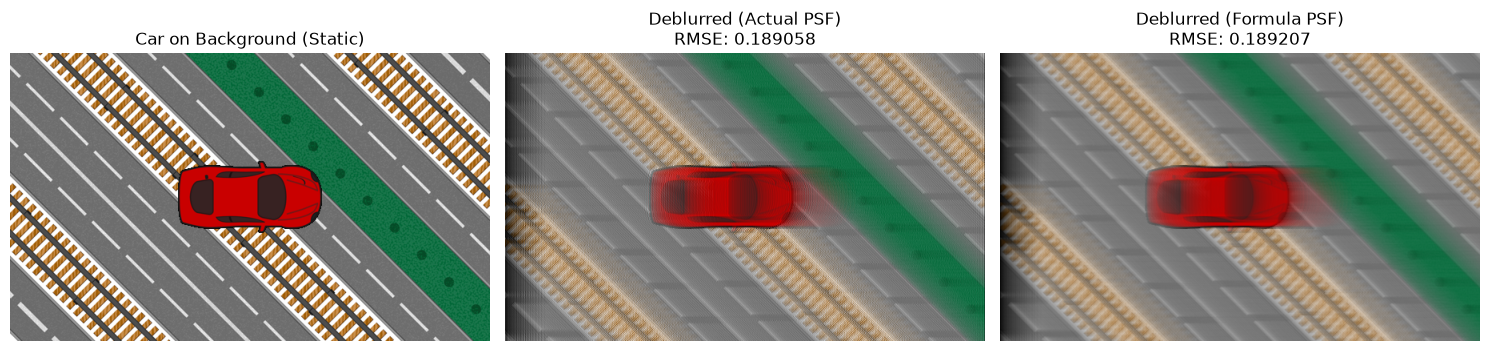

In [109]:
A_actual_pinv = np.linalg.pinv(A_actual)
deblurred_actual = np.zeros((M, N, C))
for ch in range(C):
    for row in range(M):
        deblurred_actual[row, :, ch] = A_actual_pinv @ blurred_moving_car[row, :, ch]
deblurred_actual = np.clip(deblurred_actual, 0, 1)
rmse_actual = compute_rmse(composite, deblurred_actual)
print(f"RMSE for actual PSF deblurring: {rmse_actual:.6f}")

A_formula_pinv = np.linalg.pinv(A_formula)
deblurred_formula = np.zeros((M, N, C))
for ch in range(C): 
    for row in range(M):
        deblurred_formula[row, :, ch] = A_formula_pinv @ blurred_moving_car[row, :, ch]
deblurred_formula = np.clip(deblurred_formula, 0, 1)
rmse_formula = compute_rmse(composite, deblurred_formula)
print(f"RMSE for formula PSF deblurring: {rmse_formula:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(composite)
axes[0].set_title('Car on Background (Static)')
axes[0].axis('off')
axes[1].imshow(deblurred_actual)
axes[1].set_title(f'Deblurred (Actual PSF)\nRMSE: {rmse_actual:.6f}')
axes[1].axis('off')
axes[2].imshow(deblurred_formula)
axes[2].set_title(f'Deblurred (Formula PSF)\nRMSE: {rmse_formula:.6f}')
axes[2].axis('off')
plt.tight_layout()
plt.show()